## 1. Setup

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from tslearn.datasets import UCR_UEA_datasets

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import RidgeClassifierCV, LogisticRegressionCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

import feets
import light_curve as lc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Data

In [2]:
ds = UCR_UEA_datasets()
X_train, y_train_raw, X_test, y_test_raw = ds.load_dataset('LSST')

# tslearn returns string labels — encode to contiguous integers
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)
N_CLASSES = len(le.classes_)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'Classes ({N_CLASSES}): {le.classes_}')

X_train: (2459, 36, 6)  y_train: (2459,)
X_test:  (2466, 36, 6)   y_test:  (2466,)
Classes (14): ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']


## 3. Preprocessing

feature extractor expects input shape `(n, n_channels, seq_len)`.  
tslearn returns `(n, seq_len, n_channels)` → we transpose in the Dataset.  

In [3]:
# mask of samples where NO band is all-zero
valid_mask = ~(X_test == 0).all(axis=1).any(axis=1)
print(f'{valid_mask.sum()} valid samples out of {len(X_test)}')

X_test = X_test[valid_mask]
y_test = y_test[valid_mask]

print(f'X_test: {X_test.shape}  y_test: {y_test.shape}')

2465 valid samples out of 2466
X_test: (2465, 36, 6)  y_test: (2465,)


In [4]:
# change from (n, 36, 6) to (n, 6, 36)
X_train = np.transpose(X_train, (0, 2, 1))
X_test  = np.transpose(X_test, (0, 2, 1))
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (2459, 6, 36)  y_train: (2459,)
X_test:  (2465, 6, 36)   y_test:  (2465,)


## 4. Utilities

In [5]:
COLORS = [
    "#ca1b46",'#3cb44b','#ffe119','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#fabed4','#469990','#dcbeff',
    '#9A6324','#fffac8'
]

results  = {}   # name → {macro_f1, acc}
all_preds = {}  # name → predicted labels on test set


def record(name, y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc      = accuracy_score(y_true, y_pred)
    print(f'{name:45s}  macro-F1={macro_f1:.4f}  acc={acc:.4f}')
    results[name]   = {'macro_f1': macro_f1, 'acc': acc}
    all_preds[name] = y_pred
    return macro_f1, acc

## 5. Feature Extraction

### Library `light-curve`

In [6]:
extractor = lc.Extractor(
    lc.Amplitude(),
    lc.AndersonDarlingNormal(),
    lc.BeyondNStd(nstd=1),
    lc.Cusum(),
    lc.Eta(),
    lc.EtaE(),
    lc.ExcessVariance(),
    lc.InterPercentileRange(quantile=0.25),
    lc.Kurtosis(),
    # lc.LinearFit(),
    # lc.LinearTrend(),
    lc.MagnitudePercentageRatio(),
    lc.MaximumSlope(),
    lc.Mean(),
    lc.MeanVariance(),
    lc.Median(),
    lc.MedianAbsoluteDeviation(),
    lc.MedianBufferRangePercentage(quantile=0.1),
    lc.OtsuSplit(),
    lc.PercentAmplitude(),
    lc.PercentDifferenceMagnitudePercentile(),
    lc.ReducedChi2(),
    lc.Skew(),
    lc.StandardDeviation(),
    lc.StetsonK(),
    lc.WeightedMean(),
)

t = np.arange(36).astype(np.float64)
err = np.ones(36, dtype=np.float64)

def extract_lc_all_passbands(data):
    # data: shape (n_samples, 6, 36)
    all_features = []
    for sample in data:
        sample_features = []
        for pb in range(6):
            flux = sample[pb]
            feats = extractor(t, flux, err)
            feats[extractor.names.index('mean_variance')] = np.abs(feats[extractor.names.index('mean_variance')])
            sample_features.append(feats)
        all_features.append(np.concatenate(sample_features))
    return np.array(all_features)

In [7]:
Z_train = extract_lc_all_passbands(X_train)
Z_test = extract_lc_all_passbands(X_test)

print(f'Z_train: {Z_train.shape}')
print(f'Z_test:  {Z_test.shape}')

Z_train: (2459, 162)
Z_test:  (2465, 162)


## 6. Modeling

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
Z_train = scaler.fit_transform(Z_train)
Z_test = scaler.transform(Z_test)

### Statistical Classifiers

In [9]:
ridge_probe = RidgeClassifierCV(
    alphas=np.logspace(-3, 3, 10),
    scoring='f1_macro',
    cv=cv,
    class_weight='balanced'
)
ridge_probe.fit(Z_train, y_train)
_, _ = record('RidgeClassifierCV', y_test, ridge_probe.predict(Z_test))

RidgeClassifierCV                              macro-F1=0.3887  acc=0.3533


In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=8,
    refit=True,
)

rf_grid.fit(Z_train, y_train)
_ = record('RandomForestClassifier', y_test, rf_grid.predict(Z_test))

RandomForestClassifier                         macro-F1=0.5565  acc=0.6247


In [11]:
lr = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 10),
    cv=cv,
    scoring='f1_macro',
    max_iter=5_000,
    class_weight='balanced',
    n_jobs=8,
    refit=True,
    random_state=42,
    l1_ratios=(0,),
    use_legacy_attributes=False
)

lr.fit(Z_train, y_train)
_ = record('LogisticRegressionCV', y_test, lr.predict(Z_test))

LogisticRegressionCV                           macro-F1=0.4838  acc=0.4921


### MLP

In [12]:
X_train_tensor = torch.tensor(Z_train, dtype=torch.float32)
X_test_tensor = torch.tensor(Z_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 39
Number of test batches: 39


In [15]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, output_dim=1, dropout_rate=0.2):
        super(MLP, self).__init__()
        
        self.network = nn.Sequential(
            # First hidden layer
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Second hidden layer
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Output layer
            nn.Linear(hidden_dim2, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# Initialize the model
input_size = Z_train.shape[1]
model = MLP(input_dim=input_size, hidden_dim1=64, hidden_dim2=32, output_dim=N_CLASSES)
model = model.to(DEVICE)

In [16]:
def class_weights_tensor():
    """Balanced class weights as a GPU tensor for CrossEntropyLoss."""
    w = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_train)
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)

# 1. Use CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor())
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 25

for epoch in range(num_epochs):
    
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1) # Get the index of the max log-probability
        train_total += targets.size(0)
        train_correct += (predicted == targets).sum().item()
        
    train_loss = train_loss / len(train_loader.dataset)
    train_acc = 100 * train_correct / train_total
    
    # --- EVALUATION PHASE ---
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item() * inputs.size(0)
            
            # Calculate test accuracy
            _, predicted = torch.max(outputs.data, 1)
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()
            
    test_loss = test_loss / len(test_loader.dataset)
    test_acc = 100 * test_correct / test_total
    
    # --- PRINT PROGRESS ---
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"| Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% "
              f"| Test Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%")

Epoch [1/25] | Train Loss: 2.5364, Acc: 7.40% | Test Loss: 2.5534, Acc: 17.61%
Epoch [5/25] | Train Loss: 1.5856, Acc: 34.49% | Test Loss: 1.7299, Acc: 39.03%
Epoch [10/25] | Train Loss: 1.3485, Acc: 39.49% | Test Loss: 1.5597, Acc: 42.03%
Epoch [15/25] | Train Loss: 1.1967, Acc: 42.50% | Test Loss: 1.5033, Acc: 45.80%
Epoch [20/25] | Train Loss: 1.1475, Acc: 44.45% | Test Loss: 1.5468, Acc: 45.03%
Epoch [25/25] | Train Loss: 1.0997, Acc: 45.18% | Test Loss: 1.5201, Acc: 46.25%


In [17]:
y_pred = []
model.eval()
with torch.no_grad():
    for inputs, _ in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        y_pred.extend(predicted.cpu().numpy())

_ = record('MLP', y_test, y_pred)

MLP                                            macro-F1=0.4808  acc=0.4625


## Results Summary

In [18]:
df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Strategy'})
df = df.sort_values('macro_f1', ascending=False)
print(df.to_string(index=False))

              Strategy  macro_f1      acc
RandomForestClassifier  0.556479 0.624746
  LogisticRegressionCV  0.483850 0.492089
                   MLP  0.480800 0.462475
     RidgeClassifierCV  0.388712 0.353347


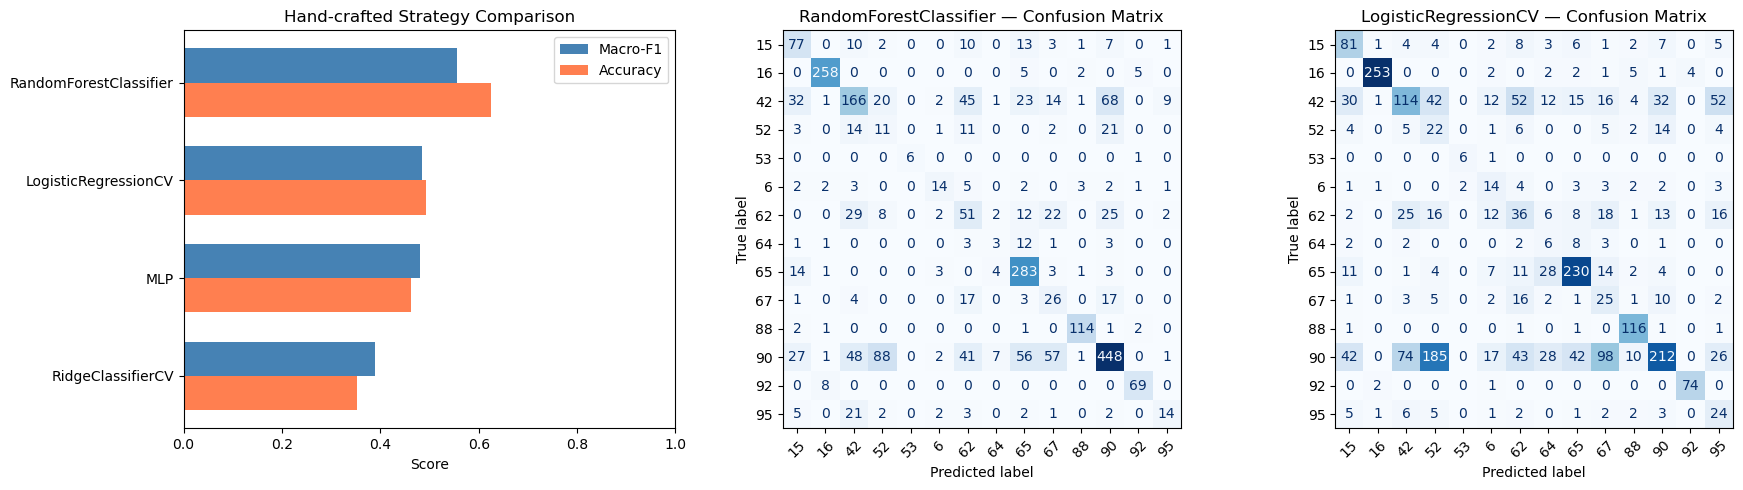

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Horizontal bar chart ───────────────────────────────────────────────────────
names  = df['Strategy'].tolist()
f1s    = df['macro_f1'].tolist()
accs   = df['acc'].tolist()
y      = np.arange(len(names))
height = 0.35

ax = axes[0]
ax.barh(y - height/2, f1s,  height, label='Macro-F1', color='steelblue')
ax.barh(y + height/2, accs, height, label='Accuracy', color='coral')
ax.set_yticks(y)
ax.set_yticklabels([n.split('.')[0] for n in names])
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title('Hand-crafted Strategy Comparison')
ax.invert_yaxis()
ax.legend()

# ── Confusion matrices (top 2 strategies by macro-F1) ────────────────────────
top2_names = df.sort_values('macro_f1', ascending=False)['Strategy'].head(2).tolist()

for ax, name in zip(axes[1:], top2_names):
    preds = all_preds[name]
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=le.classes_,
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(f'{name} — Confusion Matrix')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/hcf_results.png', dpi=150, bbox_inches='tight')
plt.show()